# LendMind

### 1) Importing Libraries

In [25]:
#!pip install numpy==2.2.0
#!pip install pandas==2.2.3
#!pip install matplotlib==3.9.3

In [26]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 2) Read & Understand The Data

In [27]:
all_data = pd.read_csv(r"..\data\archive\loan.csv")

In [28]:
all_data.shape

(2260668, 145)

--> select the output ('loan_status')

In [29]:
all_data = all_data[all_data['loan_status'].isin(['Fully Paid', 'Charged Off'])]
all_data['loan_status'] = all_data['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
all_data.shape

(1303607, 145)

fix Imbalanced Data that appears after build and evalute random forest model

it was: 79936 rows with class 0 and 20064 rows with class 1 

In [74]:
df_class0 = all_data[all_data['loan_status'] == 0].sample(n=50000, random_state= 42)
df_class1 = all_data[all_data['loan_status'] == 1].sample(n=50000, random_state= 42)
df= pd.concat([df_class0,df_class1])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.shape

(100000, 145)

In [31]:
'''
old cell before fix imbalanced data:
We will take a random sample from the dataset (all_data), for example 100k rows:
--> "frac = 100000 / 1303607 = 0.07671"

df = all_data.sample(frac= 0.07671, random_state= 42)
df.shape
'''

'\nold cell before fix imbalanced data:\nWe will take a random sample from the dataset (all_data), for example 100k rows:\n--> "frac = 100000 / 1303607 = 0.07671"\n\ndf = all_data.sample(frac= 0.07671, random_state= 42)\ndf.shape\n'

In [32]:
df.sample(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
6185,NaN,NaN,12000,12000,12000.0,60 months,12.49,269.92,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
40933,NaN,NaN,6000,6000,6000.0,36 months,13.99,205.04,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
84830,NaN,NaN,10000,10000,10000.0,36 months,9.44,320.05,B,B1,...,7611.25,72.42,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3086,NaN,NaN,23325,23325,23325.0,60 months,24.08,672.10,F,F2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
93951,NaN,NaN,14625,14625,14625.0,36 months,18.06,529.17,D,D2,...,NaN,NaN,Cash,Y,Feb-2019,BROKEN,Nov-2018,4724.73,40.0,12.0


B) dealing with Null values

In [76]:
df = df.loc[:, df.isnull().mean()<0.4]
df.shape

(100000, 87)

In [34]:
df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
98121,8400,8400,8400.0,36 months,13.49,285.02,C,C2,On Road Supervisor,7 years,...,100.0,0.0,0.0,302853.0,56718.0,12200.0,53504.0,N,Cash,N
38317,6400,6400,6400.0,36 months,10.42,207.78,B,B3,Civil Engineer,< 1 year,...,100.0,0.0,0.0,97065.0,75474.0,9000.0,79565.0,N,Cash,N
42692,12500,12500,12500.0,60 months,28.69,394.42,F,F1,Special Investigator,10+ years,...,25.0,0.0,0.0,480789.0,42283.0,16700.0,58102.0,N,Cash,N
62353,35000,35000,35000.0,60 months,20.99,946.68,E,E5,"HR - Training and Development Mgr, PA",10+ years,...,100.0,0.0,0.0,106413.0,76210.0,35400.0,56613.0,N,Cash,N
20075,32000,32000,32000.0,36 months,9.99,1032.40,B,B3,Compliance Officer,< 1 year,...,60.0,0.0,0.0,159678.0,29735.0,35000.0,0.0,N,Cash,N


C) Remove columns where all cells have the same value (Zero Variance Filter)

In [77]:
df = df.loc[:, df.nunique()>1]
df.shape

(100000, 83)

In [36]:
df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
2078,12000,12000,12000.0,36 months,9.99,387.15,B,B3,Forklift operator,10+ years,...,0.0,0.0,0.0,85870.0,61010.0,11000.0,59470.0,N,Cash,N
26715,8000,8000,8000.0,36 months,7.90,250.33,A,A4,Plant Manager,10+ years,...,25.0,1.0,0.0,15200.0,7002.0,6100.0,0.0,N,Cash,N
80992,4200,4200,4200.0,36 months,14.65,144.88,C,C5,NaN,NaN,...,83.3,1.0,0.0,168220.0,45459.0,11900.0,52920.0,N,Cash,N
37118,9775,9775,9750.0,36 months,22.45,375.60,E,E5,CNA,2 years,...,75.0,0.0,0.0,117141.0,41007.0,7800.0,33948.0,N,Cash,N
30045,7200,7200,7200.0,36 months,11.39,237.06,B,B3,Caregiver,< 1 year,...,66.7,0.0,0.0,52514.0,33469.0,26500.0,25014.0,N,Cash,N


D) High Cardinality Filter

In [78]:
string_columns = df.select_dtypes(include='object').columns
string_df = df[string_columns]
hated_columns = string_df.loc[:, (string_df.nunique() > 50)].columns
df = df.drop(columns=hated_columns)
df.shape

(100000, 75)

E) Multicollinearity Filter

In [79]:
corr_matrix = df.select_dtypes(include=['number']).corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
df = df.drop(columns=to_drop)
df.shape

(100000, 68)

['recoveries', 'total_rec_prncp', 'last_pymnt_amnt', 'total_pymnt', 'loan_amnt', 'installment', 'total_rec_int', 'debt_settlement_flag_Y', 'int_rate', 'term_ 60 months', 'total_rec_late_fee', 'revol_bal', 'dti', 'bc_open_to_buy', 'avg_cur_bal']


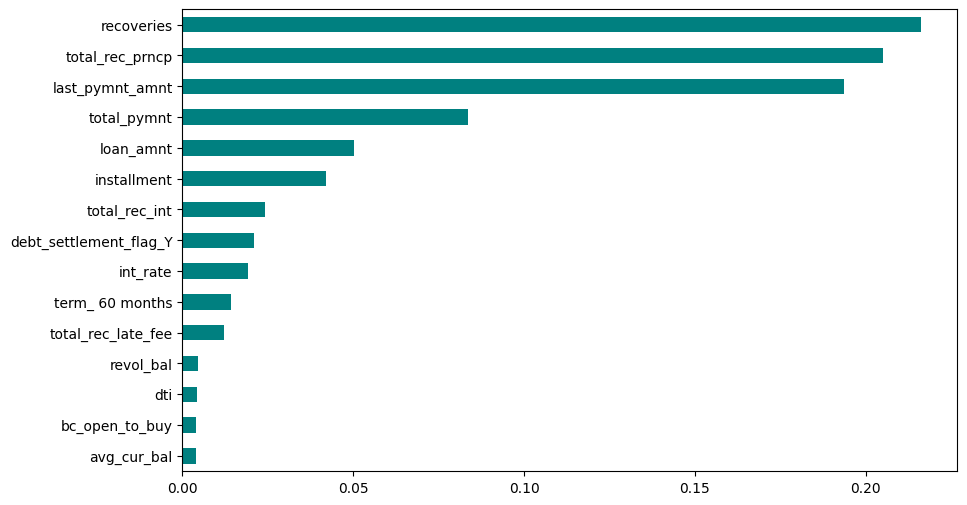

In [49]:
'''
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_encoded = pd.get_dummies(X, drop_first=True)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_encoded, y)

importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_15_features = importances.sort_values(ascending=False).head(15).index.tolist()

print(top_15_features)

plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.show()
'''

F) Preventing Data Leakage

In [80]:
leakage_columns = [
    'recoveries', 'collection_recovery_fee', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt',
    'out_prncp', 'out_prncp_inv', 'debt_settlement_flag' 
]

cols_to_drop = [col for col in leakage_columns if col in df.columns]
df_safe = df.drop(columns=cols_to_drop)
print(df_safe.shape)
print(f"cols_to_drop:\n{cols_to_drop}")

(100000, 61)
cols_to_drop:
['recoveries', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt', 'debt_settlement_flag']


✅ The top 15 columns were successfully extracted, and they are:
1- int_rate
2- dti
3- installment
4- annual_inc
5- revol_util
6- avg_cur_bal
7- revol_bal
8- bc_open_to_buy
9- tot_cur_bal
10- mo_sin_old_rev_tl_op
11- loan_amnt
12- bc_util
13- total_bc_limit
14- total_bal_ex_mort
15- total_rev_hi_lim
----------------------------------------
Final data size (15 features + 1 goal): (100000, 16)


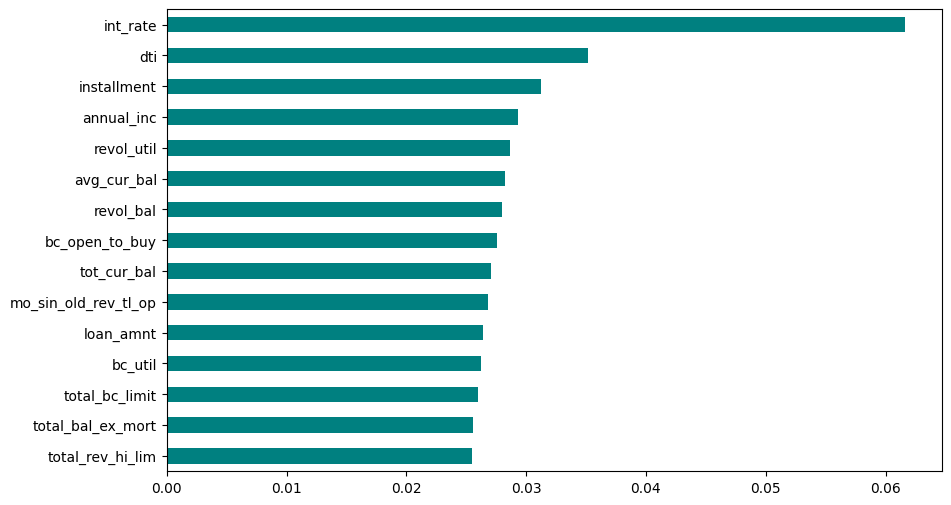

In [81]:
from sklearn.ensemble import RandomForestClassifier

X = df_safe.drop(columns=['loan_status'])
y = df_safe['loan_status']
X_encoded = pd.get_dummies(X, drop_first=True).fillna(-999)


rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_encoded, y)

importances = pd.Series(rf_selector.feature_importances_, index=X_encoded.columns)
top_15_features = importances.sort_values(ascending=False).head(15).index.tolist()

df_final = X_encoded[top_15_features].copy()
df_final['loan_status'] = y


print("✅ The top 15 columns were successfully extracted, and they are:")
for i, feature in enumerate(top_15_features, 1):
    print(f"{i}- {feature}")

print("-" * 40)
print("Final data size (15 features + 1 goal):", df_final.shape)


plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.show()


In [82]:
df_final.to_csv(r'..\data\cleaned_data.csv', index=False)
print("Cleaned data successfully saved!")

Cleaned data successfully saved!
